# Accumulated Local Effects (ALE) Analysis for EMC Dataset

This notebook analyzes the accumulated local effects on the same feature set as the SHAP analysis.
We use Leave-One-Subject-Out (LOSO) cross-validation with proper ALE computation:

1. For each fold, fit the full pipeline on training subjects
2. Compute quantile bins on training data of that fold
3. Compute ALE curve on training data using the fitted model
4. Aggregate across folds with proper interpolation and weighting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import tqdm
from scipy import interpolate
from scipy.stats import t, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

DATA_FOLDER = '/space/gzanardini/emc_whole/split'
# Best parameters from SHAP analysis
best_parameters = {
    'spectral': ('Cz',          10 ,    'std'),
    'cwt':      ('BipolarDB',   2,      'median'),
    'dwt':      ('Laplacian',   10,     'median'),
    'mst':      ('BipolarDB',   60,     'median'),
    'sst':      ('CAR',         10,     'median'),
    'cc':       ('CAR',         1,      'std'),
    'plv':      ('Laplacian',   60,      'kurt'),
    'gcc':      ('CAR',         60,      'median'),
    'gplv':     ('Laplacian',   2,      'std'),
    'utm':      ('Laplacian',   20,     'std')
}

In [2]:
def load_data():
    """Load and prepare the dataset."""
    description = pd.read_csv(f'{DATA_FOLDER}/description.csv')
    labels = description['epilepsy'].to_numpy()
    subjects = description['subject'].to_numpy()
    unique_subjects = np.unique(description['subject'])
    
    subject_labels = []
    for subj in unique_subjects:
        lbl = labels[subjects == subj][0]
        subject_labels.append([subj, lbl])
    subject_labels = np.array(subject_labels)
    
    return description, labels, subjects, unique_subjects, subject_labels

def load_feature_data(feature_name):
    """Load and preprocess feature data using the best parameters for the given feature."""
    montage, segment_length, combiner = best_parameters[feature_name]
    data = np.load(f'{DATA_FOLDER}/{feature_name}_{montage}_{segment_length}s_{combiner}.npy')
    data = handle_complex_numbers(data)
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
    return data, montage, segment_length, combiner

def handle_complex_numbers(features):
    """Handle complex numbers and infinite values in features."""
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

In [3]:
# Load data
description, labels, subjects, unique_subjects, subject_labels = load_data()

# Load PLV feature data using best parameters
feature_name = 'plv'
data, montage, segment_length, combiner = load_feature_data(feature_name)

# Channel names for PLV feature naming
chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

def plv_index_to_name(idx, ch=None):
    bands = ['raw','delta','theta','alpha','beta','gamma']
    if ch is None:
        ch = ['FP1_Lap','F3_Lap','C3_Lap','P3_Lap','F7_Lap','T3_Lap','T5_Lap','O1_Lap',
              'FZ_Lap','CZ_Lap','PZ_Lap','FP2_Lap','F4_Lap','C4_Lap','P4_Lap',
              'F8_Lap','T4_Lap','T6_Lap','O2_Lap']

    P = len(ch)*(len(ch)-1)//2  # 171
    band_id, pair_id = divmod(idx, P)

    # Recover the (j,k) pair that lives at position pair_id
    j = next(j for j in range(1, len(ch)) if j*(j+1)//2 > pair_id)
    k = pair_id - j*(j-1)//2

    return f"PLV_{bands[band_id]}_{ch[j]}-{ch[k]}"

feature_names = [plv_index_to_name(i, ch=chs) for i in range(data.shape[1])]
print(f"Loaded {feature_name} data: {data.shape}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")

Loaded plv data: (141, 1026)
Montage: Laplacian, Segment length: 60s, Combiner: kurt


In [4]:
def compute_ale_1d(model, X_train, feature_idx, n_bins=20):
    """
    Compute 1D Accumulated Local Effects for a single feature.
    
    Parameters:
    -----------
    model : fitted model
        The trained model to explain
    X_train : np.ndarray
        Training data used to compute quantile bins
    feature_idx : int
        Index of the feature to compute ALE for
    n_bins : int
        Number of quantile bins to use
    
    Returns:
    --------
    ale_values : np.ndarray
        ALE values at bin centers
    bin_centers : np.ndarray
        Feature values at bin centers
    bin_counts : np.ndarray
        Number of samples in each bin
    """
    feature_values = X_train[:, feature_idx]
    
    # Remove NaN values
    valid_mask = ~np.isnan(feature_values)
    if not np.any(valid_mask):
        return np.array([]), np.array([]), np.array([])
    
    feature_values = feature_values[valid_mask]
    X_valid = X_train[valid_mask]
    
    # Create quantile bins on training data
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(feature_values, quantiles)
    
    # Ensure unique bin edges
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) < 3:  # Need at least 2 bins
        return np.array([]), np.array([]), np.array([])
    
    # Compute ALE
    ale_values = []
    bin_centers = []
    bin_counts = []
    
    for i in range(len(bin_edges) - 1):
        # Find samples in this bin
        in_bin = (feature_values >= bin_edges[i]) & (feature_values < bin_edges[i + 1])
        if i == len(bin_edges) - 2:  # Last bin includes right edge
            in_bin = (feature_values >= bin_edges[i]) & (feature_values <= bin_edges[i + 1])
        
        if np.sum(in_bin) == 0:
            continue
            
        X_bin = X_valid[in_bin]
        
        # Create copies with feature values at bin edges
        X_lower = X_bin.copy()
        X_upper = X_bin.copy()
        X_lower[:, feature_idx] = bin_edges[i]
        X_upper[:, feature_idx] = bin_edges[i + 1]
        
        # Get predictions
        pred_lower = model.predict_proba(X_lower)[:, 1]
        pred_upper = model.predict_proba(X_upper)[:, 1]
        
        # Local effect for this bin
        local_effect = np.mean(pred_upper - pred_lower)
        ale_values.append(local_effect)
        
        # Bin center and count
        bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
        bin_counts.append(np.sum(in_bin))
    
    if len(ale_values) == 0:
        return np.array([]), np.array([]), np.array([])
    
    ale_values = np.array(ale_values)
    bin_centers = np.array(bin_centers)
    bin_counts = np.array(bin_counts)
    
    # Accumulate local effects
    ale_cumsum = np.cumsum(ale_values)
    
    # Center ALE (subtract weighted mean)
    weighted_mean = np.average(ale_cumsum, weights=bin_counts)
    ale_cumsum -= weighted_mean
    
    return ale_cumsum, bin_centers, bin_counts

In [5]:
def interpolate_ale_to_common_grid(ale_values, bin_centers, common_grid):
    """
    Interpolate ALE values to a common grid.
    
    Parameters:
    -----------
    ale_values : np.ndarray
        ALE values from one fold
    bin_centers : np.ndarray
        Bin centers from one fold
    common_grid : np.ndarray
        Common grid to interpolate to
    
    Returns:
    --------
    interpolated_ale : np.ndarray
        ALE values interpolated to common grid
    """
    if len(ale_values) == 0 or len(bin_centers) == 0:
        return np.full(len(common_grid), np.nan)
    
    # Only interpolate within the range of the original data
    min_val, max_val = bin_centers.min(), bin_centers.max()
    
    # Find valid grid points
    valid_mask = (common_grid >= min_val) & (common_grid <= max_val)
    
    interpolated_ale = np.full(len(common_grid), np.nan)
    
    if np.any(valid_mask):
        # Linear interpolation
        f = interpolate.interp1d(bin_centers, ale_values, kind='linear', 
                               bounds_error=False, fill_value=np.nan)
        interpolated_ale[valid_mask] = f(common_grid[valid_mask])
    
    return interpolated_ale

In [6]:
def aggregate_ale_across_folds(fold_results, n_grid_points=100):
    """
    Aggregate ALE results across folds.
    
    Parameters:
    -----------
    fold_results : list
        List of (ale_values, bin_centers, bin_counts, n_train) for each fold
    n_grid_points : int
        Number of points in common grid
    
    Returns:
    --------
    common_grid : np.ndarray
        Common grid points
    mean_ale : np.ndarray
        Mean ALE across folds
    std_ale : np.ndarray
        Standard deviation of ALE across folds
    ci_lower : np.ndarray
        Lower 95% confidence interval
    ci_upper : np.ndarray
        Upper 95% confidence interval
    """
    # Extract valid results
    valid_results = [(ale, centers, counts, n_train) for ale, centers, counts, n_train in fold_results 
                    if len(ale) > 0 and len(centers) > 0]
    
    if len(valid_results) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])
    
    # Determine common grid range
    all_centers = np.concatenate([centers for _, centers, _, _ in valid_results])
    min_val, max_val = np.percentile(all_centers, [5, 95])  # Use 5-95% range to avoid outliers
    
    common_grid = np.linspace(min_val, max_val, n_grid_points)
    
    # Interpolate each fold to common grid
    interpolated_ales = []
    fold_weights = []
    
    for ale_values, bin_centers, bin_counts, n_train in valid_results:
        # Center the ALE values (in case not done already)
        ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
        
        # Interpolate to common grid
        interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, common_grid)
        interpolated_ales.append(interpolated)
        fold_weights.append(n_train)
    
    interpolated_ales = np.array(interpolated_ales)
    fold_weights = np.array(fold_weights)
    
    # Compute weighted statistics
    valid_mask = ~np.isnan(interpolated_ales)
    
    mean_ale = np.full(n_grid_points, np.nan)
    std_ale = np.full(n_grid_points, np.nan)
    ci_lower = np.full(n_grid_points, np.nan)
    ci_upper = np.full(n_grid_points, np.nan)
    
    for i in range(n_grid_points):
        valid_i = valid_mask[:, i]
        if np.sum(valid_i) > 1:  # Need at least 2 folds for statistics
            values = interpolated_ales[valid_i, i]
            weights = fold_weights[valid_i]
            
            # Weighted mean
            mean_ale[i] = np.average(values, weights=weights)
            
            # Unbiased standard deviation (not weighted for simplicity)
            std_ale[i] = np.std(values, ddof=1)
            
            # 95% confidence interval using t-distribution
            n_folds = len(values)
            t_val = t.ppf(0.975, n_folds - 1)
            margin = t_val * std_ale[i] / np.sqrt(n_folds)
            ci_lower[i] = mean_ale[i] - margin
            ci_upper[i] = mean_ale[i] + margin
    
    return common_grid, mean_ale, std_ale, ci_lower, ci_upper

In [ ]:
def prepare_ale_plot_data(common_grid, mean_ale, std_ale, ci_lower, ci_upper, 
                         feature_name, feature_idx, montage, segment_length, combiner,
                         individual_folds=None, p_value=None, feature_values=None):
    """
    Prepare ALE plot data for later styling.
    
    Parameters:
    -----------
    feature_values : np.ndarray, optional
        Raw feature values for rugplot
    
    Returns:
    --------
    plot_data : dict
        Dictionary containing all data needed for plotting
    """
    # Filter valid data points
    valid_mask = ~np.isnan(mean_ale)
    
    plot_data = {
        'common_grid': common_grid,
        'mean_ale': mean_ale,
        'std_ale': std_ale,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'valid_mask': valid_mask,
        'feature_name': feature_name,
        'feature_idx': feature_idx,
        'montage': montage,
        'segment_length': segment_length,
        'combiner': combiner,
        'individual_folds': individual_folds,
        'p_value': p_value,
        'feature_values': feature_values
    }
    
    return plot_data

def plot_ale_from_data(plot_data, title_suffix="", figsize=(10, 6), show_rugplot=True):
    """
    Create ALE plot from prepared data with optional rugplot.
    
    Parameters:
    -----------
    show_rugplot : bool
        Whether to show rugplot of feature values
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot individual fold curves (faint)
    if plot_data['individual_folds'] is not None:
        for fold_ale in plot_data['individual_folds']:
            ax.plot(plot_data['common_grid'], fold_ale, 'lightgray', alpha=0.4, linewidth=0.5)
    
    # Plot confidence interval and mean
    valid_mask = plot_data['valid_mask']
    if np.any(valid_mask):
        ax.fill_between(plot_data['common_grid'][valid_mask], 
                        plot_data['ci_lower'][valid_mask], 
                        plot_data['ci_upper'][valid_mask], 
                        alpha=0.3, color='blue', label='95% CI')
        
        ax.plot(plot_data['common_grid'][valid_mask], 
                plot_data['mean_ale'][valid_mask], 
                'b-', linewidth=2, label='Mean ALE')
        
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Add rugplot if feature values are available
    if show_rugplot and plot_data['feature_values'] is not None:
        # Filter out NaN values
        valid_feature_vals = plot_data['feature_values'][~np.isnan(plot_data['feature_values'])]
        
        if len(valid_feature_vals) > 0:
            # Get y-axis limits to position rugplot at bottom
            y_min, y_max = ax.get_ylim()
            rug_height = (y_max - y_min) * 0.02  # 2% of y-axis range
            rug_y = y_min + rug_height
            
            # Sample feature values if too many (for performance)
            if len(valid_feature_vals) > 1000:
                sample_indices = np.random.choice(len(valid_feature_vals), 1000, replace=False)
                rug_values = valid_feature_vals[sample_indices]
            else:
                rug_values = valid_feature_vals
            
            # Create rugplot
            ax.plot(rug_values, np.full(len(rug_values), rug_y), '|', 
                   color='darkgray', alpha=0.6, markersize=20, markeredgewidth=0.5,
                   label='Data points')
    
    # Title with p-value if available
    title = f'ALE Plot for {feature_names[plot_data["feature_idx"]]}\n'
    title += f'Montage: {plot_data["montage"]}, Length: {plot_data["segment_length"]}s, Combiner: {plot_data["combiner"]}'
    if plot_data['p_value'] is not None:
        title += f'\nMann-Whitney U p-value: {plot_data["p_value"]:.4f}'
    
    ax.set_xlabel(f'Feature {plot_data["feature_idx"]} Value')
    ax.set_ylabel('ALE (Change in Prediction)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig

In [8]:
def compute_mann_whitney_features(data, labels, alpha=0.05, top_n=5):
    """
    Compute Mann-Whitney U test for each feature and return top N features with lowest p-values.
    
    Parameters:
    -----------
    data : np.ndarray
        Feature matrix (n_samples, n_features)
    labels : np.ndarray
        Binary labels (0/1)
    alpha : float
        Significance level for Bonferroni correction
    top_n : int
        Number of top features to return
    
    Returns:
    --------
    top_features : np.ndarray
        Indices of top N features with lowest corrected p-values
    p_values : np.ndarray
        Original p-values for all features
    corrected_p_values : np.ndarray
        Bonferroni corrected p-values
    """
    n_features = data.shape[1]
    p_values = np.full(n_features, 1.0)
    statistics = np.full(n_features, 0.0)
    
    # Separate groups
    group_0 = labels == 0  # Non-epileptic
    group_1 = labels == 1  # Epileptic
    
    print(f"Computing Mann-Whitney U test for {n_features} features...")
    print(f"Group 0 (non-epileptic): {np.sum(group_0)} samples")
    print(f"Group 1 (epileptic): {np.sum(group_1)} samples")
    
    for i in tqdm.tqdm(range(n_features), desc="Computing Mann-Whitney U tests"):
        feature_data = data[:, i]
        
        # Remove NaN values
        valid_mask = ~np.isnan(feature_data)
        if np.sum(valid_mask) < 10:  # Need at least 10 valid samples
            continue
            
        feature_valid = feature_data[valid_mask]
        labels_valid = labels[valid_mask]
        
        group_0_valid = labels_valid == 0
        group_1_valid = labels_valid == 1
        
        if np.sum(group_0_valid) < 3 or np.sum(group_1_valid) < 3:  # Need at least 3 samples per group
            continue
            
        data_0 = feature_valid[group_0_valid]
        data_1 = feature_valid[group_1_valid]
        
        try:
            # Mann-Whitney U test
            statistic, p_value = mannwhitneyu(data_0, data_1, alternative='two-sided')
            p_values[i] = p_value
            statistics[i] = statistic
        except Exception as e:
            print(f"Error in feature {i}: {e}")
            continue
    
    # Bonferroni correction
    valid_tests = p_values < 1.0  # Features that were actually tested
    corrected_p_values = np.full(n_features, 1.0)
    
    if np.any(valid_tests):
        valid_p_values = p_values[valid_tests]
        _, corrected_valid, _, _ = multipletests(valid_p_values, alpha=alpha, method='bonferroni')
        corrected_p_values[valid_tests] = corrected_valid
    
    # Get top N features with lowest corrected p-values
    valid_features = np.where(valid_tests)[0]
    if len(valid_features) > 0:
        sorted_indices = np.argsort(corrected_p_values[valid_features])
        top_n_valid = valid_features[sorted_indices[:min(top_n, len(valid_features))]]
    else:
        top_n_valid = np.array([])
    
    return top_n_valid, p_values, corrected_p_values

In [9]:
# Compute Mann-Whitney U test for top 5 features only
print("=== MANN-WHITNEY U FEATURE SELECTION ===")
top_features, mw_p_values, mw_corrected_p_values = compute_mann_whitney_features(data, labels, top_n=4)

print(f"\nTop 5 features with lowest Bonferroni-corrected p-values:")
for i, feat_idx in enumerate(top_features):
    p_val = mw_p_values[feat_idx]
    corrected_p_val = mw_corrected_p_values[feat_idx]
    if feat_idx < len(feature_names):
        feat_name = feature_names[feat_idx]
    else:
        feat_name = f"Feature_{feat_idx}"
    
    print(f"  {i+1}. Feature {feat_idx}: {feat_name}")
    print(f"      Original p-value: {p_val:.2e}, Corrected p-value: {corrected_p_val:.2e}")

# Set features to analyze to only the top 5 + features 232, 224, and 587
features_to_analyze = top_features #np.concatenate([top_features, [232, 224, 587]])
print(f"Total features to analyze: {len(features_to_analyze)}")

=== MANN-WHITNEY U FEATURE SELECTION ===
Computing Mann-Whitney U test for 1026 features...
Group 0 (non-epileptic): 101 samples
Group 1 (epileptic): 40 samples


Computing Mann-Whitney U tests: 100%|██████████| 1026/1026 [00:00<00:00, 1813.10it/s]


Top 5 features with lowest Bonferroni-corrected p-values:
  1. Feature 232: PLV_delta_FP2-T5
      Original p-value: 3.39e-04, Corrected p-value: 3.48e-01
  2. Feature 327: PLV_delta_O2-P3
      Original p-value: 3.83e-04, Corrected p-value: 3.93e-01
  3. Feature 97: PLV_raw_P4-T5
      Original p-value: 7.31e-04, Corrected p-value: 7.50e-01
  4. Feature 0: PLV_raw_F3-FP1
      Original p-value: 4.49e-01, Corrected p-value: 1.00e+00
Total features to analyze: 4


In [10]:
# Compute ALE for Mann-Whitney U selected top 5 features
print("\n=== ALE ANALYSIS FOR TOP 5 MANN-WHITNEY U SELECTED FEATURES ===")
ale_results = {}

for feat_idx in tqdm.tqdm(features_to_analyze, desc='Computing ALE for top 5 features'):
    if feat_idx >= data.shape[1]:
        print(f"Skipping feature {feat_idx}: Index out of range")
        continue
        
    fold_results = []
    all_feature_values = []  # Collect feature values for rugplot
    
    # LOSO cross-validation
    for subj in tqdm.tqdm(unique_subjects, desc=f'LOSO folds for feature {feat_idx}', leave=False):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]
        
        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]
        
        # Collect feature values for rugplot (from training data)
        feature_train = X_train[:, feat_idx]
        all_feature_values.extend(feature_train[~np.isnan(feature_train)])
        
        # Handle missing values in training data
        if np.all(np.isnan(feature_train)) or len(np.unique(feature_train[~np.isnan(feature_train)])) < 3:
            continue
        
        # Train model
        ratio = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
        
        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01,
            random_state=42
        )
        
        try:
            model.fit(X_train, y_train)
            
            # Compute ALE for this fold
            ale_values, bin_centers, bin_counts = compute_ale_1d(model, X_train, feat_idx, n_bins=20)
            
            if len(ale_values) > 0:
                fold_results.append((ale_values, bin_centers, bin_counts, len(X_train)))
                
        except Exception as e:
            print(f"Error in fold {subj} for feature {feat_idx}: {e}")
            continue
    
    if len(fold_results) > 2:  # Need at least 3 folds for meaningful aggregation
        # Aggregate across folds
        common_grid, mean_ale, std_ale, ci_lower, ci_upper = aggregate_ale_across_folds(fold_results)
        
        ale_results[feat_idx] = {
            'common_grid': common_grid,
            'mean_ale': mean_ale,
            'std_ale': std_ale,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_folds': len(fold_results),
            'fold_results': fold_results,
            'p_value': mw_p_values[feat_idx] if feat_idx < len(mw_p_values) else 1.0,
            'corrected_p_value': mw_corrected_p_values[feat_idx] if feat_idx < len(mw_corrected_p_values) else 1.0,
            'feature_values': np.array(all_feature_values)  # Store for rugplot
        }
        
        print(f"Feature {feat_idx}: {len(fold_results)} successful folds")
    else:
        print(f"Feature {feat_idx}: Insufficient folds ({len(fold_results)}), skipping")

print(f"\nCompleted ALE analysis for {len(ale_results)} features")


=== ALE ANALYSIS FOR TOP 5 MANN-WHITNEY U SELECTED FEATURES ===


Computing ALE for top 5 features:  25%|██▌       | 1/4 [03:59<11:59, 239.73s/it]

Feature 232: 141 successful folds


Computing ALE for top 5 features:  50%|█████     | 2/4 [08:02<08:03, 241.57s/it]

Feature 327: 141 successful folds


Computing ALE for top 5 features:  75%|███████▌  | 3/4 [11:57<03:58, 238.59s/it]

Feature 97: 141 successful folds


Computing ALE for top 5 features: 100%|██████████| 4/4 [15:55<00:00, 238.89s/it]

Feature 0: 141 successful folds

Completed ALE analysis for 4 features


In [11]:
# Prepare plot data for all features (no plotting yet)
print("\n=== PREPARING PLOT DATA FOR TOP 5 FEATURES ===")

plot_data_collection = {}

if len(ale_results) > 0:
    for feat_idx, results in ale_results.items():
        # Collect individual fold ALE curves for plotting
        individual_folds = []
        for ale_values, bin_centers, bin_counts, n_train in results['fold_results']:
            ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
            interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, results['common_grid'])
            individual_folds.append(interpolated)
        
        # Prepare plot data with feature values for rugplot
        plot_data = prepare_ale_plot_data(
            results['common_grid'], 
            results['mean_ale'], 
            results['std_ale'],
            results['ci_lower'], 
            results['ci_upper'],
            feature_name, 
            feat_idx, 
            montage, 
            segment_length, 
            combiner,
            individual_folds=individual_folds,
            p_value=results['corrected_p_value'],
            feature_values=results['feature_values']
        )
        
        plot_data_collection[feat_idx] = plot_data
        
        print(f"Prepared plot data for feature {feat_idx}")

    print(f"Plot data prepared for {len(plot_data_collection)} features")
else:
    print("No successful ALE results to prepare plot data for")


=== PREPARING PLOT DATA FOR TOP 5 FEATURES ===
Prepared plot data for feature 232
Prepared plot data for feature 327
Prepared plot data for feature 97
Prepared plot data for feature 0
Plot data prepared for 4 features


In [12]:
import pickle
import os
from datetime import datetime

def save_ale_results(ale_results, plot_data_collection, feature_name, montage, 
                    segment_length, combiner, top_features, mw_p_values, 
                    mw_corrected_p_values, save_dir='ale_results'):
    """
    Save ALE analysis results to disk.
    
    Parameters:
    -----------
    ale_results : dict
        Raw ALE computation results
    plot_data_collection : dict
        Prepared plot data
    feature_name : str
        Name of the feature type
    montage, segment_length, combiner : str/int
        Analysis parameters
    top_features : np.ndarray
        Selected feature indices
    mw_p_values, mw_corrected_p_values : np.ndarray
        Mann-Whitney test results
    save_dir : str
        Directory to save results
    
    Returns:
    --------
    save_path : str
        Path where results were saved
    """
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Create filename with timestamp and parameters
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"ale_results_{feature_name}_{montage}_{segment_length}s_{combiner}_{timestamp}.pkl"
    save_path = os.path.join(save_dir, filename)
    
    # Prepare data to save
    save_data = {
        'ale_results': ale_results,
        'plot_data_collection': plot_data_collection,
        'metadata': {
            'feature_name': feature_name,
            'montage': montage,
            'segment_length': segment_length,
            'combiner': combiner,
            'timestamp': timestamp,
            'n_features_analyzed': len(ale_results),
            'n_plot_data_prepared': len(plot_data_collection)
        },
        'statistical_tests': {
            'top_features': top_features,
            'mw_p_values': mw_p_values,
            'mw_corrected_p_values': mw_corrected_p_values
        }
    }
    
    # Save to pickle file
    with open(save_path, 'wb') as f:
        pickle.dump(save_data, f)
    
    print(f"ALE results saved to: {save_path}")
    print(f"  Features analyzed: {len(ale_results)}")
    print(f"  Plot data prepared: {len(plot_data_collection)}")
    
    return save_path

def load_ale_results(load_path):
    """
    Load ALE analysis results from disk.
    
    Parameters:
    -----------
    load_path : str
        Path to saved results file
    
    Returns:
    --------
    ale_results : dict
        Raw ALE computation results
    plot_data_collection : dict
        Prepared plot data
    metadata : dict
        Analysis metadata
    statistical_tests : dict
        Statistical test results
    """
    if not os.path.exists(load_path):
        raise FileNotFoundError(f"Results file not found: {load_path}")
    
    with open(load_path, 'rb') as f:
        save_data = pickle.load(f)
    
    ale_results = save_data['ale_results']
    plot_data_collection = save_data['plot_data_collection']
    metadata = save_data['metadata']
    statistical_tests = save_data['statistical_tests']
    
    print(f"ALE results loaded from: {load_path}")
    print(f"  Analysis timestamp: {metadata['timestamp']}")
    print(f"  Feature type: {metadata['feature_name']}")
    print(f"  Parameters: {metadata['montage']}, {metadata['segment_length']}s, {metadata['combiner']}")
    print(f"  Features analyzed: {metadata['n_features_analyzed']}")
    print(f"  Plot data prepared: {metadata['n_plot_data_prepared']}")
    
    return ale_results, plot_data_collection, metadata, statistical_tests

def list_saved_results(save_dir='ale_results'):
    """
    List all saved ALE results in the directory.
    
    Parameters:
    -----------
    save_dir : str
        Directory containing saved results
    
    Returns:
    --------
    results_files : list
        List of tuples (filename, metadata) for each saved result
    """
    if not os.path.exists(save_dir):
        print(f"No results directory found: {save_dir}")
        return []
    
    results_files = []
    pkl_files = [f for f in os.listdir(save_dir) if f.endswith('.pkl')]
    
    print(f"Found {len(pkl_files)} saved ALE result files in {save_dir}:")
    
    for i, filename in enumerate(sorted(pkl_files)):
        filepath = os.path.join(save_dir, filename)
        try:
            with open(filepath, 'rb') as f:
                save_data = pickle.load(f)
            
            metadata = save_data['metadata']
            file_size = os.path.getsize(filepath) / (1024*1024)  # MB
            
            print(f"  {i+1}. {filename}")
            print(f"      Feature: {metadata['feature_name']}, "
                  f"Montage: {metadata['montage']}, "
                  f"Length: {metadata['segment_length']}s")
            print(f"      Combiner: {metadata['combiner']}, "
                  f"Analyzed: {metadata['n_features_analyzed']} features")
            print(f"      Timestamp: {metadata['timestamp']}, "
                  f"Size: {file_size:.1f} MB")
            
            results_files.append((filename, metadata))
            
        except Exception as e:
            print(f"  Error reading {filename}: {e}")
    
    return results_files


=== CREATING PLOTS FROM PREPARED DATA ===


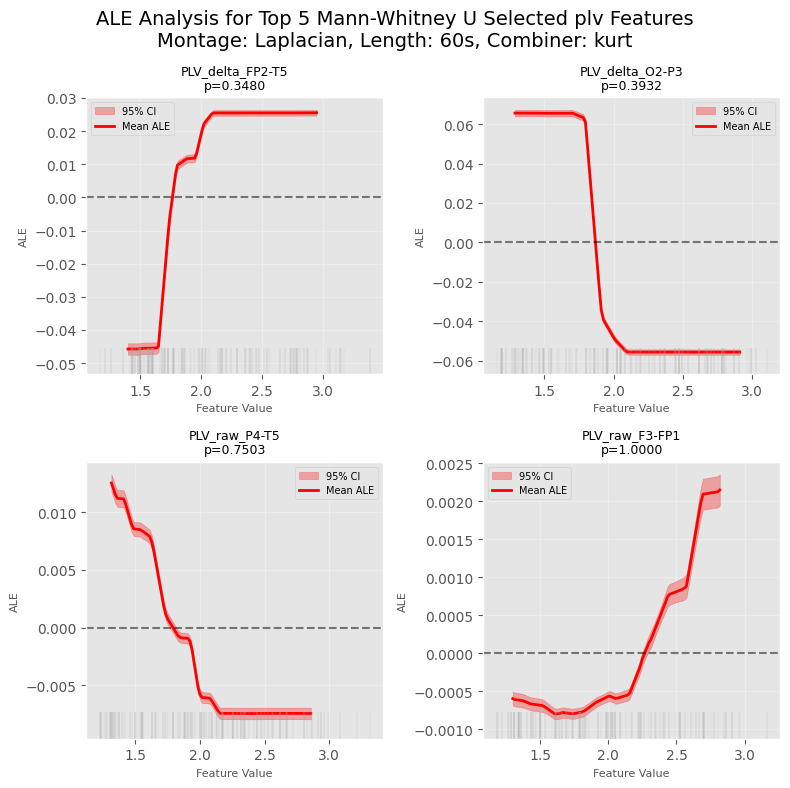


=== CREATING DETAILED INDIVIDUAL PLOTS WITH RUGPLOT ===


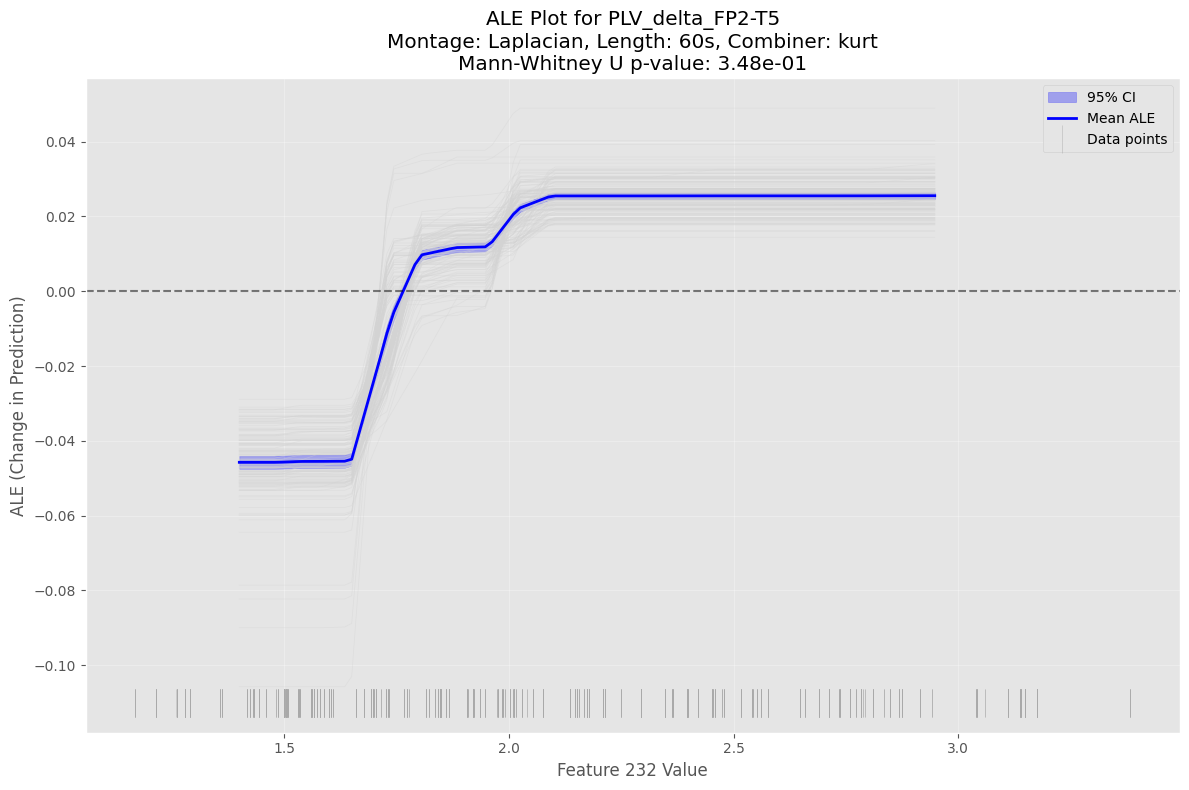

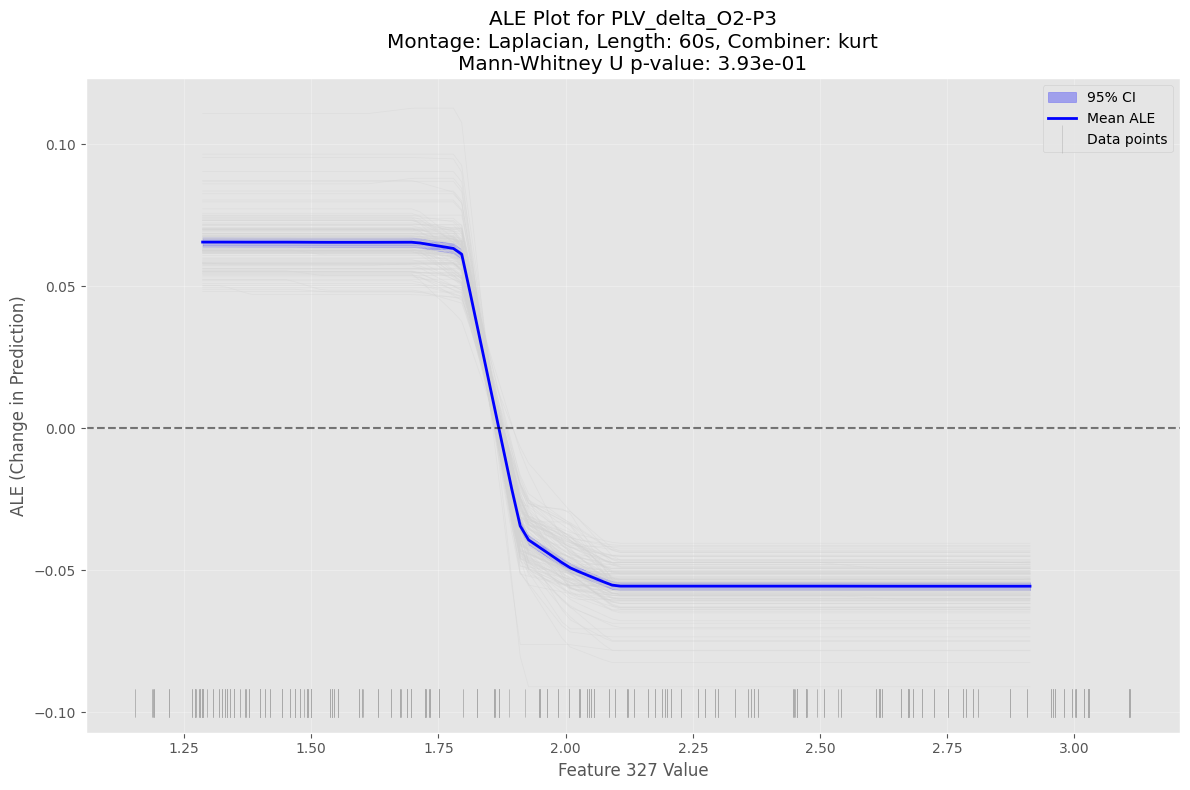

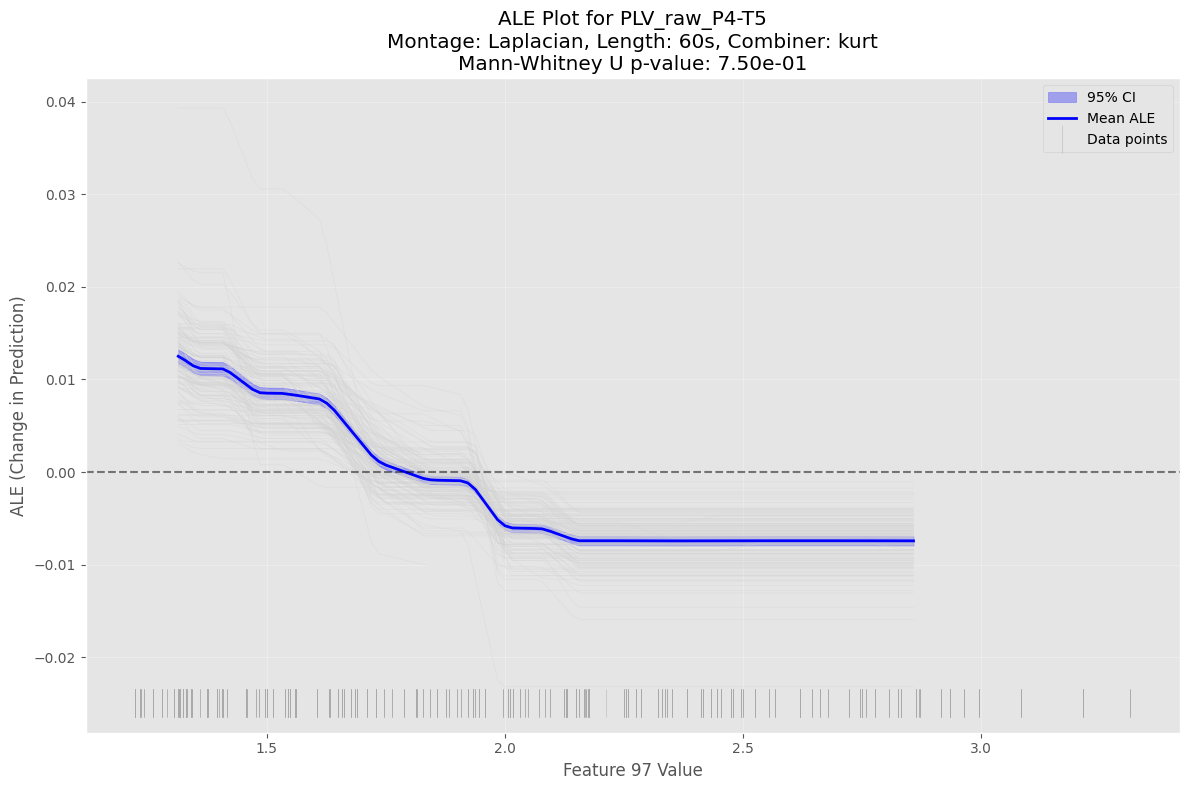

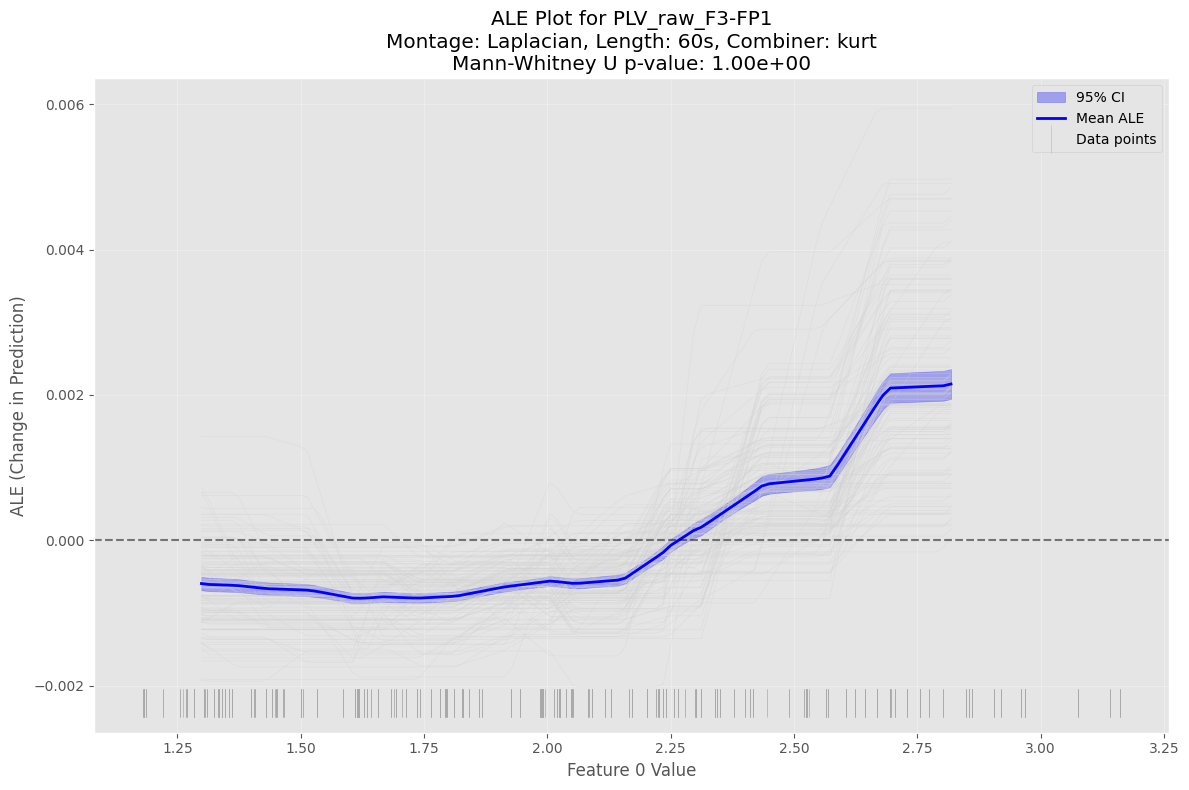

In [20]:
# Create plots using the prepared data (example usage)
print("\n=== CREATING PLOTS FROM PREPARED DATA ===")

if len(plot_data_collection) > 0:
    # Create overview plot with all top 5 features
    n_features = len(plot_data_collection)
    n_cols = min(2, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_features == 1:
        axes = [axes]
    elif n_rows == 1 and n_cols > 1:
        axes = axes.reshape(1, -1)
    
    # Sort by p-value (most significant first)
    sorted_features = sorted(plot_data_collection.items(), 
                           key=lambda x: x[1]['p_value'])
    
    for i, (feat_idx, plot_data) in enumerate(sorted_features):
        if n_rows == 1 and n_cols > 1:
            ax = axes[0, i] if n_cols > 1 else axes[i]
        elif n_rows > 1 and n_cols == 1:
            ax = axes[i]
        elif n_rows > 1 and n_cols > 1:
            row, col = i // n_cols, i % n_cols
            ax = axes[row, col]
        else:
            ax = axes
            
        plt.sca(ax)
        
        # Plot using the prepared data
        valid_mask = plot_data['valid_mask']
        if np.any(valid_mask):
            ax.fill_between(plot_data['common_grid'][valid_mask], 
                           plot_data['ci_lower'][valid_mask], 
                           plot_data['ci_upper'][valid_mask], 
                           alpha=0.3, color='red', label='95% CI')
            ax.plot(plot_data['common_grid'][valid_mask], 
                   plot_data['mean_ale'][valid_mask], 
                   'r-', linewidth=2, label='Mean ALE')
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            
            # Add simple rugplot for overview
            if plot_data['feature_values'] is not None:
                valid_feature_vals = plot_data['feature_values'][~np.isnan(plot_data['feature_values'])]
                if len(valid_feature_vals) > 0:
                    y_min, y_max = ax.get_ylim()
                    rug_height = (y_max - y_min) * 0.02  # 2% of y-axis range
                    rug_y = y_min + rug_height
                    
                    # Sample for overview plot
                    if len(valid_feature_vals) > 200:
                        sample_indices = np.random.choice(len(valid_feature_vals), 200, replace=False)
                        rug_values = valid_feature_vals[sample_indices]
                    else:
                        rug_values = valid_feature_vals
                    
                    ax.plot(rug_values, np.full(len(rug_values), rug_y), '|', 
                           color='darkgray', alpha=0.4, markersize=20, markeredgewidth=0.3)
        
        # Feature name and p-value
        if feat_idx < len(feature_names):
            title = f'{feature_names[feat_idx][:40]}\np={plot_data["p_value"]:.4f}'
        else:
            title = f'Feature {feat_idx}\np={plot_data["p_value"]:.4f}'
        
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Feature Value', fontsize=8)
        ax.set_ylabel('ALE', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    
    # Hide empty subplots
    for i in range(len(plot_data_collection), n_rows * n_cols):
        if n_rows == 1 and n_cols > 1:
            axes[0, i].set_visible(False)
        elif n_rows > 1:
            row, col = i // n_cols, i % n_cols
            axes[row, col].set_visible(False)
    
    plt.suptitle(f'ALE Analysis for Top 5 Mann-Whitney U Selected {feature_name} Features\n'
                 f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}', 
                 fontsize=14)
    plt.tight_layout()
    plt.savefig(f'ale_overview_{feature_name}_top5_mann_whitney_emc.pdf', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create individual detailed plots for each feature with rugplot
    print("\n=== CREATING DETAILED INDIVIDUAL PLOTS WITH RUGPLOT ===")
    for feat_idx, plot_data in sorted_features:
        fig = plot_ale_from_data(plot_data, 
                                figsize=(12, 8),
                                show_rugplot=True)
        plt.show()
        
        # Save individual plot
        plt.savefig(f'ale_{feature_name}_feature_{feat_idx}_mann_whitney_emc.pdf', 
                   dpi=300, bbox_inches='tight')
        plt.close()
else:
    print("No plot data available for plotting")

In [14]:
# Final summary
print("\n" + "="*60)
print("=== FINAL SUMMARY: MANN-WHITNEY U ALE ANALYSIS ===")
print("="*60)

print(f"\nFeature type: {feature_name}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")
print(f"Total features in dataset: {data.shape[1]}")
print(f"Total subjects (LOSO folds): {len(unique_subjects)}")

# Mann-Whitney U test results
n_significant_features = np.sum(mw_corrected_p_values < 0.05)
n_valid_tests = np.sum(mw_p_values < 1.0)
print(f"\nMann-Whitney U Test Results:")
print(f"  Features tested: {n_valid_tests}")
print(f"  Significant features (corrected p < 0.05): {n_significant_features}")
print(f"  Top features selected for ALE: {len(features_to_analyze)}")
print(f"  Successful ALE computations: {len(ale_results)}")

if len(ale_results) > 0:
    avg_folds = np.mean([results['n_folds'] for results in ale_results.values()])
    print(f"  Average successful folds per feature: {avg_folds:.1f}")
    
    # Report top 5 features
    print(f"\nTop 5 features by Mann-Whitney U test (analyzed):")
    for i, feat_idx in enumerate(top_features):
        if feat_idx in ale_results:
            p_val = ale_results[feat_idx]['corrected_p_value']
            n_folds = ale_results[feat_idx]['n_folds']
            
            # Calculate max ALE effect
            mean_ale = ale_results[feat_idx]['mean_ale']
            valid_mask = ~np.isnan(mean_ale)
            max_ale = np.max(np.abs(mean_ale[valid_mask])) if np.any(valid_mask) else 0
            
            if feat_idx < len(feature_names):
                feat_name = feature_names[feat_idx][:80] + "..." if len(feature_names[feat_idx]) > 80 else feature_names[feat_idx]
            else:
                feat_name = f"Feature_{feat_idx}"
            
            status = "✓ Successfully analyzed"
            print(f"  {i+1}. Feature {feat_idx}: {feat_name}")
            print(f"      Status: {status}")
            print(f"      Corrected p-value: {p_val:.2e}")
            print(f"      Max |ALE|: {max_ale:.4f}")
            print(f"      Successful folds: {n_folds}")
        else:
            status = "✗ ALE analysis failed"
            print(f"  {i+1}. Feature {feat_idx}: {status}")

print(f"\nAnalysis completed! Plot data available for {len(plot_data_collection)} features.")
print("="*60)

# Return the plot data collection for further use
print(f"\nPlot data collection contains {len(plot_data_collection)} features ready for custom styling.")


=== FINAL SUMMARY: MANN-WHITNEY U ALE ANALYSIS ===

Feature type: plv
Montage: Laplacian, Segment length: 60s, Combiner: kurt
Total features in dataset: 1026
Total subjects (LOSO folds): 141

Mann-Whitney U Test Results:
  Features tested: 1026
  Significant features (corrected p < 0.05): 0
  Top features selected for ALE: 4
  Successful ALE computations: 4
  Average successful folds per feature: 141.0

Top 5 features by Mann-Whitney U test (analyzed):
  1. Feature 232: PLV_delta_FP2-T5
      Status: ✓ Successfully analyzed
      Corrected p-value: 3.48e-01
      Max |ALE|: 0.0457
      Successful folds: 141
  2. Feature 327: PLV_delta_O2-P3
      Status: ✓ Successfully analyzed
      Corrected p-value: 3.93e-01
      Max |ALE|: 0.0656
      Successful folds: 141
  3. Feature 97: PLV_raw_P4-T5
      Status: ✓ Successfully analyzed
      Corrected p-value: 7.50e-01
      Max |ALE|: 0.0125
      Successful folds: 141
  4. Feature 0: PLV_raw_F3-FP1
      Status: ✓ Successfully analyzed
 

In [15]:
# Plot data collection is now available as 'plot_data_collection' dictionary
# Each entry contains all necessary data for creating custom plots:
# - common_grid: x-axis values
# - mean_ale: main ALE curve  
# - ci_lower, ci_upper: confidence intervals
# - individual_folds: individual fold curves
# - feature metadata (name, index, p_value, etc.)

# Example of accessing the data:
if len(plot_data_collection) > 0:
    first_feature = list(plot_data_collection.keys())[0]
    sample_data = plot_data_collection[first_feature]
    print(f"Sample plot data structure for feature {first_feature}:")
    print(f"  Keys available: {list(sample_data.keys())}")
    print(f"  Grid points: {len(sample_data['common_grid'])}")
    print(f"  Valid ALE points: {np.sum(sample_data['valid_mask'])}")
    print(f"  Individual folds: {len(sample_data['individual_folds']) if sample_data['individual_folds'] else 0}")

Sample plot data structure for feature 232:
  Keys available: ['common_grid', 'mean_ale', 'std_ale', 'ci_lower', 'ci_upper', 'valid_mask', 'feature_name', 'feature_idx', 'montage', 'segment_length', 'combiner', 'individual_folds', 'p_value', 'feature_values']
  Grid points: 100
  Valid ALE points: 100
  Individual folds: 141
